# Customer Segmentation - Final Clustering Notebook

This notebook applies and compares clustering techniques for customer segmentation. It includes K-Means model selection, final segment profiling, PCA/t-SNE/UMAP visual validation, SOM exploratory analysis, hierarchical clustering, density-based alternatives, outlier assignment and final export files.

## 1. Imports and Data Loading

In [1]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

import utils_clustering as clu

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [2]:
# Load clustering-ready dataset
df = pd.read_csv("../datasets/info_clustering_ready.csv")

# Explicit feature selection for clustering
selected_features = [

    # Customer behavior
    "number_complaints",
    "distinct_stores_visited",
    "percentage_of_products_bought_promotion",

    # Demographics
    "customer_age",
    "tenure",
    "total_children",
    "is_male",

    # Loyalty
    "customer_loyalty_flag",

    # Cyclic shopping hour
    "typical_hour_sin",
    "typical_hour_cos",

    # Geography
    "latitude",
    "longitude",

    # Education
    "education_level",

    # Spending magnitude
    "total_spend",

    # Spending preferences
    "pct_spend_groceries",
    "pct_spend_vegetables",
    "pct_spend_nonalcohol_drinks",
    "pct_spend_alcohol_drinks",
    "pct_spend_meat",
    "pct_spend_fish",
    "pct_spend_hygiene",
    "pct_spend_petfood",
    "pct_spend_technology",
]

# Final feature matrix used for clustering
X = df[selected_features]

print("Dataset shape:", X.shape)
X.head()

Dataset shape: (32047, 23)


,number_complaints,distinct_stores_visited,percentage_of_products_bought_promotion,customer_age,tenure,total_children,is_male,customer_loyalty_flag,typical_hour_sin,typical_hour_cos,...,total_spend,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology
0,0.0,0.0,1.049200,0.032258,-0.833333,0.0,0,1,0.007571,0.387135,...,-0.120744,-0.328208,-0.037253,-0.098118,-0.425625,-0.948961,-0.425489,-0.037600,0.383979,1.474190
1,-1.0,-0.5,-0.311186,-0.161290,0.333333,-1.0,0,1,-0.108516,-0.394586,...,-0.006006,-0.109752,1.632684,0.443032,-0.583949,-0.929306,-0.800456,1.682070,1.238171,-0.206544
2,-1.0,-0.5,-0.539272,-0.032258,1.666667,-2.0,1,0,0.189469,-0.767327,...,-0.333110,0.468230,0.291552,-0.754589,-0.489018,1.586341,-0.212063,0.041638,-0.062242,-0.703580
3,1.0,-1.0,-0.018274,-0.387097,-1.000000,-2.0,1,1,-0.732051,0.823443,...,-0.374801,-0.948124,-0.341181,1.908452,1.747981,1.067286,1.707989,0.037028,-0.200149,0.834914
4,2.0,-1.0,-0.207602,0.032258,-1.000000,-2.0,1,1,-0.707107,0.397198,...,0.382553,-1.640143,-0.149474,0.238192,0.175117,0.317712,0.550307,-0.532100,0.134857,3.290386


## 2. Utility Functions

The main helper functions used in this notebook are stored in `utils_clustering.py`. This keeps the notebook cleaner and makes the workflow more reusable.

In [3]:
# The utility file contains plotting, profiling, evaluation and outlier-assignment functions.
# If changes are made to utils_clustering.py during development, restart the kernel and run again.
print("Utility functions loaded from utils_clustering.py")

Utility functions loaded from utils_clustering.py


## 3. K-Means: Choosing the Number of Clusters

K-Means was tested for different values of `k`. The Elbow Method helps understand how inertia decreases as more clusters are added, while the Silhouette Score measures the average separation and cohesion of the clusters.

In [ ]:
kmeans_results = []

for k in range(2, 13):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    kmeans_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(X, labels)
    })

kmeans_results = pd.DataFrame(kmeans_results)
kmeans_results

,k,inertia,silhouette_score
0,2,557394.057897,0.199056
1,3,492345.654256,0.205475
2,4,436819.852048,0.194285
3,5,406410.049003,0.191024
4,6,383539.635549,0.138261
5,7,368591.638032,0.131318
6,8,355854.892727,0.134142
7,9,343671.261849,0.133064
8,10,334162.196595,0.137013
9,11,326656.085844,0.124708


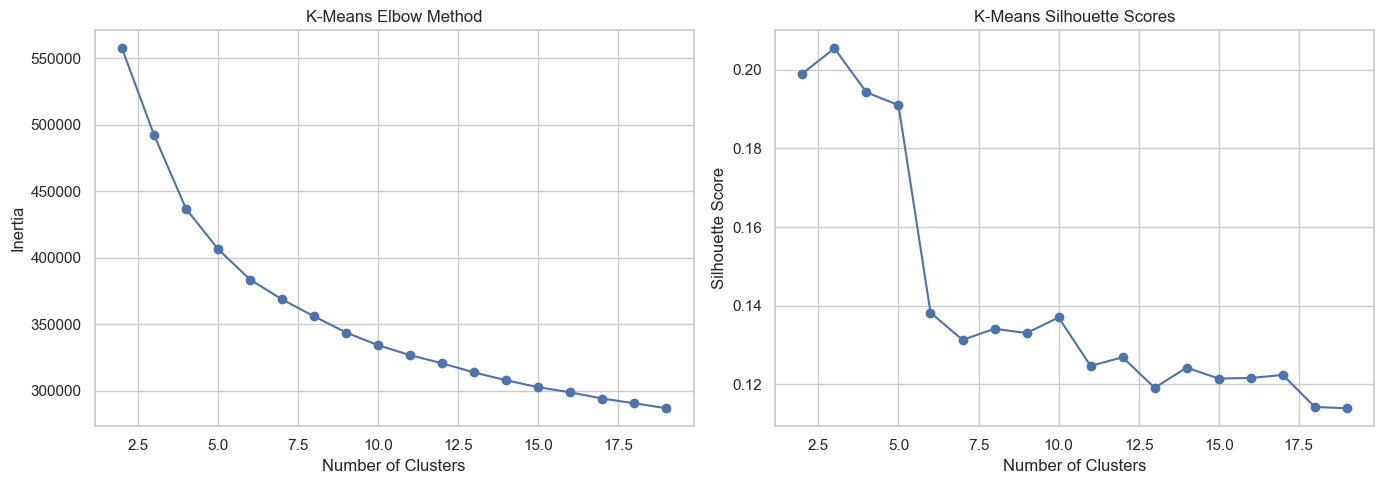

In [7]:
clu.plot_elbow_and_silhouette(kmeans_results)

Although `k=2` may achieve a higher silhouette score, it is too broad for customer segmentation. The objective is not only to maximize a metric, but also to obtain useful, interpretable and actionable segments. Therefore, `k=3`, `k=4` and `k=5` were compared in more detail.

KMEANS k=3

Cluster distribution:
0     3018
1     6158
2    22871
Name: count, dtype: int64

Metrics:


,Model,Clusters,Silhouette Score
0,KMeans k=3,3,0.205475



Cluster profile:


,cluster_size,cluster_percentage,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,customer_loyalty_flag,is_male,education_level
kmeans_cluster_3,,,,,,,,,,,,,,,,,,,,,
0,3018,9.42,0.01,0.10,1.02,0.37,0.91,1.40,1.07,1.02,...,0.21,0.61,0.32,0.45,-0.13,-0.31,0.51,0.68,0.51,1.14
1,6158,19.22,-0.03,-0.28,-0.57,0.07,0.21,0.52,0.04,0.24,...,0.98,0.96,0.69,0.74,0.44,0.74,2.18,0.52,0.48,0.47
2,22871,71.37,-0.11,0.18,0.38,0.35,-0.03,-0.04,-0.17,-0.02,...,0.02,-0.03,-0.04,-0.05,0.35,0.16,-0.11,0.62,0.50,1.02


Explained variance with 2 components: 0.3372


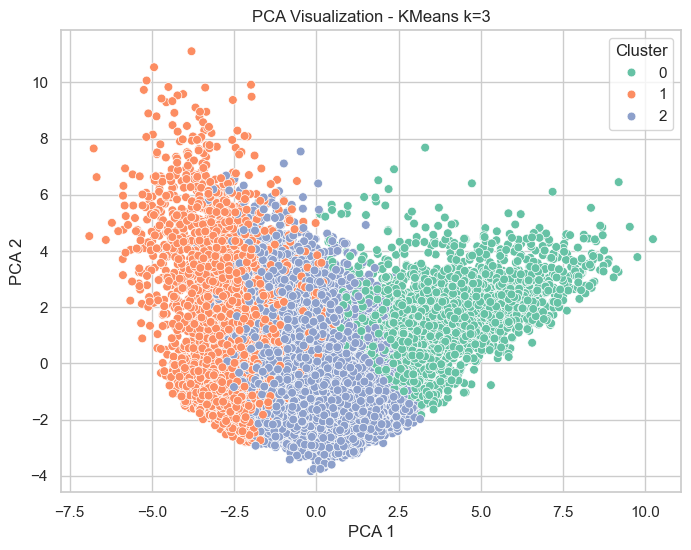

KMEANS k=4

Cluster distribution:
0     6341
1     3602
2     2966
3    19138
Name: count, dtype: int64

Metrics:


,Model,Clusters,Silhouette Score
0,KMeans k=4,4,0.194285



Cluster profile:


,cluster_size,cluster_percentage,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,customer_loyalty_flag,is_male,education_level
kmeans_cluster_4,,,,,,,,,,,,,,,,,,,,,
0,6341,19.79,-0.31,0.26,-0.44,1.14,0.22,-0.24,-0.66,-0.37,...,1.27,0.18,-0.01,-0.04,1.87,1.09,0.30,0.62,0.51,1.34
1,3602,11.24,0.04,-0.67,-0.43,-0.33,0.30,0.89,0.25,0.46,...,0.47,1.04,0.42,0.66,-0.42,0.00,3.08,0.47,0.47,0.11
2,2966,9.26,-0.01,0.10,0.99,0.38,0.92,1.43,1.09,1.03,...,0.24,0.64,0.34,0.47,-0.12,-0.31,0.54,0.68,0.51,1.15
3,19138,59.72,-0.04,0.17,0.51,0.13,-0.10,0.03,-0.01,0.09,...,-0.17,0.01,0.10,0.06,0.02,0.06,-0.11,0.61,0.50,0.91


Explained variance with 2 components: 0.3372


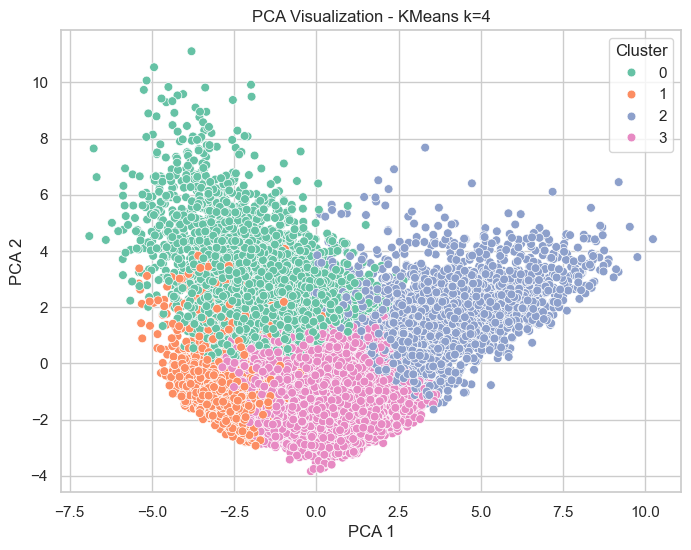

KMEANS k=5

Cluster distribution:
0     2888
1     3311
2    17575
3     5590
4     2683
Name: count, dtype: int64

Metrics:


,Model,Clusters,Silhouette Score
0,KMeans k=5,5,0.191024



Cluster profile:


,cluster_size,cluster_percentage,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,customer_loyalty_flag,is_male,education_level
kmeans_cluster_5,,,,,,,,,,,,,,,,,,,,,
0,2888,9.01,-0.04,0.10,1.00,0.39,0.93,1.46,1.10,1.04,...,0.22,0.64,0.32,0.45,-0.13,-0.33,0.54,0.68,0.51,1.14
1,3311,10.33,0.03,-0.75,-0.40,-0.35,0.30,0.92,0.24,0.45,...,0.37,0.97,0.30,0.53,-0.51,-0.09,3.18,0.46,0.47,0.06
2,17575,54.84,-0.03,0.16,0.57,0.08,-0.09,0.05,0.02,0.12,...,-0.21,0.01,0.07,0.05,-0.02,0.00,-0.12,0.61,0.50,0.89
3,5590,17.44,-0.35,0.21,-0.27,1.50,0.27,-0.30,-0.92,-0.54,...,1.05,-0.06,-0.74,-0.57,1.75,0.60,0.20,0.60,0.51,1.43
4,2683,8.37,-0.03,0.36,-0.68,-0.01,-0.06,0.00,0.22,0.22,...,1.16,0.78,1.99,1.48,1.15,1.88,0.53,0.67,0.49,0.89


Explained variance with 2 components: 0.3372


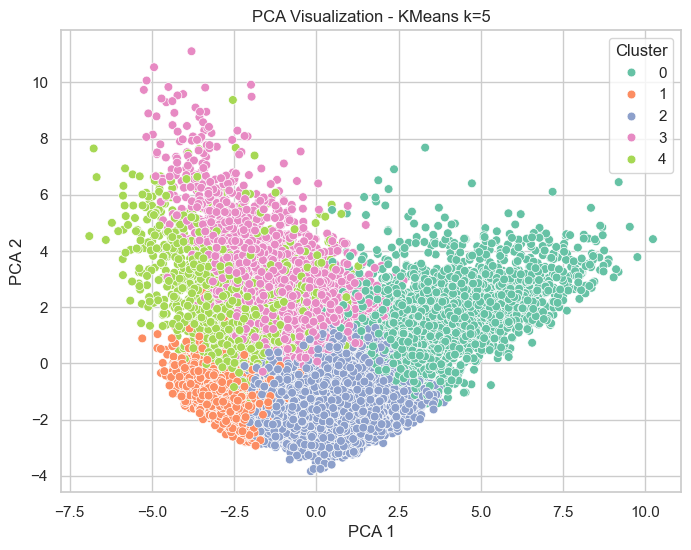

In [8]:
kmeans_comparison = {}

for k in [3, 4, 5]:

    print("=" * 80)
    print(f"KMEANS k={k}")

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    temp_df = df.copy()
    temp_df[f"kmeans_cluster_{k}"] = labels

    profile = clu.create_cluster_profile(
        temp_df,
        cluster_col=f"kmeans_cluster_{k}"
    )

    metrics = clu.evaluate_clustering(
        X,
        labels,
        model_name=f"KMeans k={k}"
    )

    kmeans_comparison[k] = {
        "model": model,
        "labels": labels,
        "df": temp_df,
        "profile": profile,
        "metrics": metrics
    }

    print("\nCluster distribution:")
    print(clu.cluster_distribution(labels))

    print("\nMetrics:")
    display(metrics)

    print("\nCluster profile:")
    display(profile)

    clu.plot_pca_clusters(
        X,
        labels,
        title=f"PCA Visualization - KMeans k={k}"
    )

## 4. Final K-Means Model

K-Means with `k=5` was selected because it provides a stronger segmentation structure than `k=3`, while still keeping acceptable separation and interpretability. This solution gives more actionable customer groups without fragmenting the population excessively.

In [22]:
best_k = 4

kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans_model.fit_predict(X)

customer_info_kmeans = df.copy()
customer_info_kmeans["kmeans_cluster"] = kmeans_labels

clu.cluster_distribution(kmeans_labels)

0     6341
1     3602
2     2966
3    19138
Name: count, dtype: int64

In [23]:
kmeans_metrics = clu.evaluate_clustering(
    X,
    kmeans_labels,
    model_name="KMeans k=4"
)

kmeans_metrics

,Model,Clusters,Silhouette Score
0,KMeans k=4,4,0.194285


## 5. Silhouette Analysis

The silhouette plot shows how well each customer fits within its assigned cluster compared with the nearest alternative cluster. In customer segmentation, moderate silhouette values are common because real customer behavior is complex and overlapping.

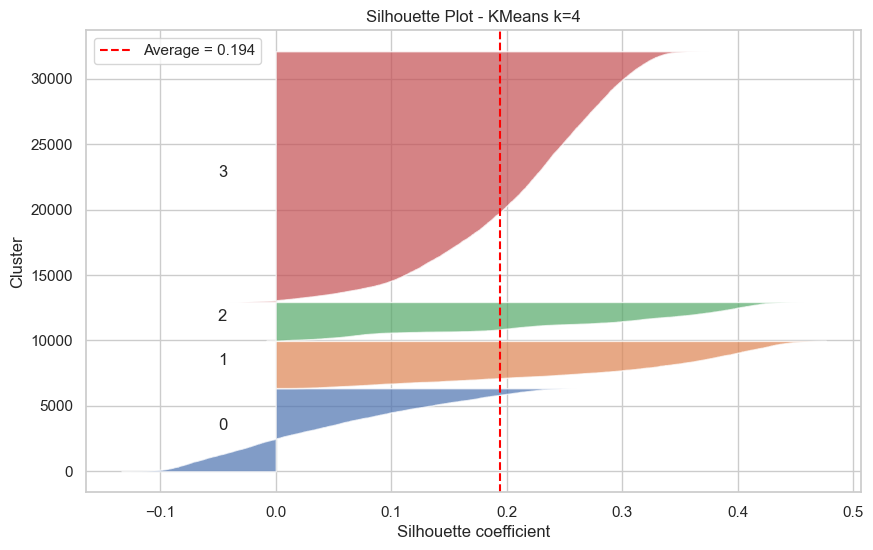

In [24]:
clu.plot_silhouette_analysis(
    X,
    kmeans_labels,
    title="Silhouette Plot - KMeans k=4"
)

## 6. Cluster Profiling

The cluster profile summarizes the average characteristics of each segment. Because the input dataset is scaled, values above zero indicate variables that are above the overall average, while values below zero indicate variables below the overall average.

In [26]:
# Add the FINAL k=4 cluster labels to the dataframe
customer_info_kmeans["kmeans_cluster"] = kmeans_labels

profile_features = [
    "kmeans_cluster",
    "number_complaints",
    "distinct_stores_visited",
    "customer_age",
    "tenure",
    "total_children",
    "is_male",
    "customer_loyalty_flag",
    "total_spend",
    "pct_spend_groceries",
    "pct_spend_vegetables",
    "pct_spend_nonalcohol_drinks",
    "pct_spend_alcohol_drinks",
    "pct_spend_meat",
    "pct_spend_fish",
    "pct_spend_hygiene",
    "pct_spend_petfood",
    "pct_spend_technology",
    "latitude",
    "longitude",
    "education_level"
]

profile_df = customer_info_kmeans[profile_features]

kmeans_profile = clu.create_cluster_profile(
    profile_df,
    cluster_col="kmeans_cluster"
)

display(kmeans_profile)

,cluster_size,cluster_percentage,number_complaints,distinct_stores_visited,customer_age,tenure,total_children,is_male,customer_loyalty_flag,total_spend,...,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,latitude,longitude,education_level
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,6341,19.79,-0.31,0.26,0.09,-0.05,-0.19,0.51,0.62,-0.47,...,1.27,0.18,-0.01,-0.04,1.87,1.09,0.30,0.20,0.39,1.34
1,3602,11.24,0.04,-0.67,0.03,-0.32,-1.40,0.47,0.47,0.11,...,0.47,1.04,0.42,0.66,-0.42,0.00,3.08,-0.01,-0.41,0.11
2,2966,9.26,-0.01,0.10,0.09,0.36,4.34,0.51,0.68,1.19,...,0.24,0.64,0.34,0.47,-0.12,-0.31,0.54,-0.01,-0.01,1.15
3,19138,59.72,-0.04,0.17,-0.03,0.04,-0.34,0.50,0.61,0.32,...,-0.17,0.01,0.10,0.06,0.02,0.06,-0.11,0.02,0.06,0.91


In [27]:
top_cluster_features = clu.get_top_cluster_features(
    kmeans_profile,
    top_n=5
)

top_cluster_features

,cluster,top_positive_features,top_negative_features
0,0,"[pct_spend_vegetables, pct_spend_hygiene, educ...","[tenure, total_children, number_complaints, to..."
1,1,"[pct_spend_technology, pct_spend_alcohol_drink...","[longitude, pct_spend_hygiene, distinct_stores..."
2,2,"[total_children, total_spend, education_level,...","[latitude, longitude, pct_spend_hygiene, pct_s..."
3,3,"[education_level, customer_loyalty_flag, is_ma...","[customer_age, number_complaints, pct_spend_te..."


## 7. Final Segment Names

Based on the final `k=4` cluster profile, the numerical clusters were translated into business-oriented customer segment names.

In [28]:
customer_info_kmeans, segment_names = clu.add_segment_names(
    customer_info_kmeans,
    cluster_col="kmeans_cluster",
    name_col="segment_name"
)

segment_names

{0: 'Promotion-Oriented Regulars',
 1: 'Healthy Lifestyle Buyers',
 2: 'Premium Grocery & Pet Buyers',
 3: 'Tech-Focused Customers',
 4: 'Family Loyal Customers'}

In [13]:
# Keep customer_id as an integer identifier for readability
if "customer_id" in customer_info_kmeans.columns:
    customer_info_kmeans["customer_id"] = customer_info_kmeans["customer_id"].astype(int)


In [14]:
customer_info_kmeans[[
    "customer_id",
    "kmeans_cluster",
    "segment_name"
]].head()

,customer_id,kmeans_cluster,segment_name
0,3,0,Promotion-Oriented Regulars
1,4,1,Healthy Lifestyle Buyers
2,5,0,Promotion-Oriented Regulars
3,7,3,Tech-Focused Customers
4,8,3,Tech-Focused Customers


## Segment Interpretation

### Cluster 0 — Promotion-Oriented Regulars
Largest segment, characterized by high promotion usage and relatively balanced spending behavior.

### Cluster 1 — Healthy Lifestyle Buyers
Customers with high relative spending on vegetables, hygiene products and non-alcoholic drinks, suggesting a health-conscious profile.

### Cluster 2 — Premium Grocery & Pet Buyers
Customers with strong spending concentration in meat, fish, pet food, hygiene and non-alcoholic drinks.

### Cluster 3 — Tech-Focused Customers
Customers strongly associated with technology spending, with fewer store visits and lower loyalty participation.

### Cluster 4 — Family Loyal Customers
Customers with larger households, higher product diversity, higher total spend and stronger loyalty.

## 8. Centroids and Cluster Size Distribution

The centroid table represents the average position of each K-Means cluster in the scaled feature space. To avoid an overly dense visualization, only the most relevant centroid features are plotted in the heatmap.

In [15]:
kmeans_centroids = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=X.columns
)

kmeans_centroids.insert(
    0,
    "cluster",
    kmeans_centroids.index
)

kmeans_centroids.round(3)

,cluster,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_age,education_level,tenure,total_children,total_spend,...,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,is_male,customer_loyalty_flag
0,0,-0.031,0.156,0.169,0.460,-0.041,0.454,0.039,-0.347,0.360,...,0.055,-0.212,0.016,0.066,0.054,-0.017,0.005,-0.123,0.499,0.613
1,1,-0.352,0.208,-0.134,-0.333,0.092,0.686,-0.083,-0.098,-0.323,...,2.181,1.046,-0.052,-0.742,-0.571,1.732,0.598,0.212,0.509,0.583
2,2,-0.020,0.354,0.166,0.629,0.088,0.442,0.079,-0.430,-0.695,...,0.618,1.156,0.783,2.008,1.469,1.128,1.880,0.531,0.490,0.668
3,3,0.048,-0.753,-0.107,0.053,0.042,0.036,-0.345,-1.468,0.190,...,-0.281,0.370,0.925,0.308,0.531,-0.510,-0.103,3.254,0.472,0.475
4,4,-0.042,0.109,1.201,-0.101,0.093,0.571,0.365,4.388,1.228,...,0.017,0.222,0.635,0.318,0.445,-0.136,-0.337,0.537,0.510,0.677


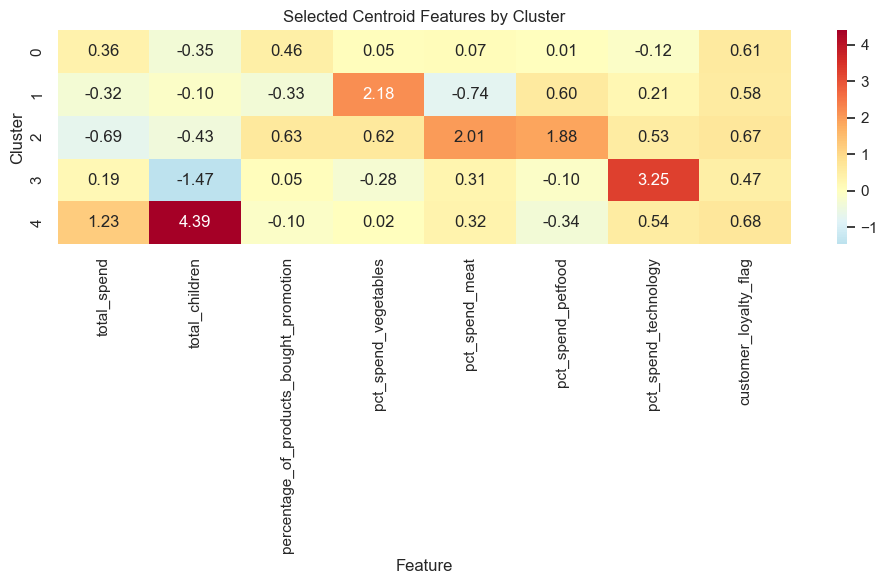

In [16]:
selected_centroid_features = [
    "total_spend",
    "total_children",
    "percentage_of_products_bought_promotion",
    "pct_spend_vegetables",
    "pct_spend_meat",
    "pct_spend_petfood",
    "pct_spend_technology",
    "customer_loyalty_flag"
]

clu.plot_selected_centroid_heatmap(
    kmeans_centroids,
    features=selected_centroid_features,
    cluster_col="cluster"
)


In [17]:
cluster_sizes = customer_info_kmeans["kmeans_cluster"].value_counts().sort_index()

cluster_sizes_df = pd.DataFrame({
    "cluster": cluster_sizes.index,
    "count": cluster_sizes.values,
    "percentage": np.round(
        cluster_sizes.values / len(customer_info_kmeans) * 100,
        2
    )
})

cluster_sizes_df

,cluster,count,percentage
0,0,17543,55.02
1,1,5578,17.49
2,2,2661,8.35
3,3,3221,10.10
4,4,2883,9.04


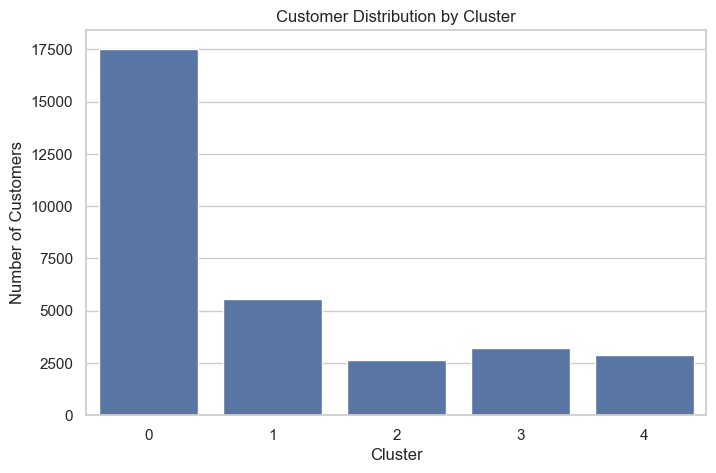

In [18]:
clu.plot_cluster_sizes(
    customer_info_kmeans,
    cluster_col="kmeans_cluster"
)

## 9. Cluster Profiling Visualizations

The following plots compare the average values of key behavioral, demographic and spending variables across the final K-Means clusters.

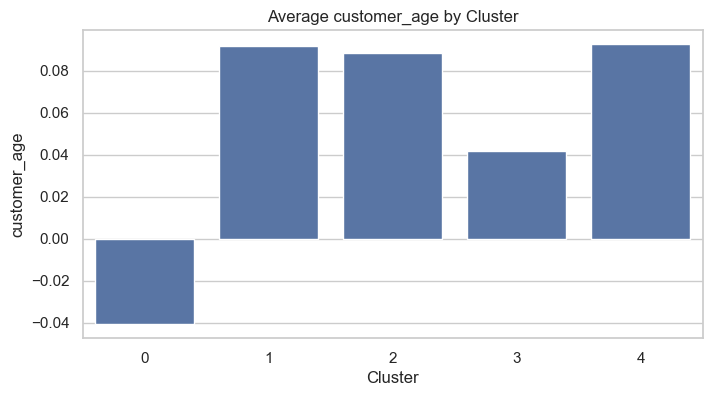

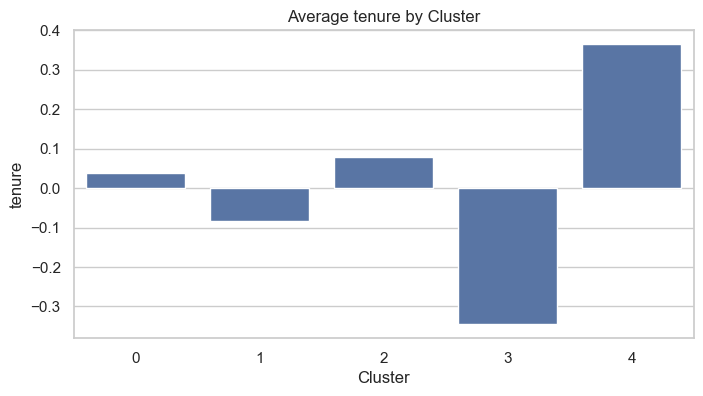

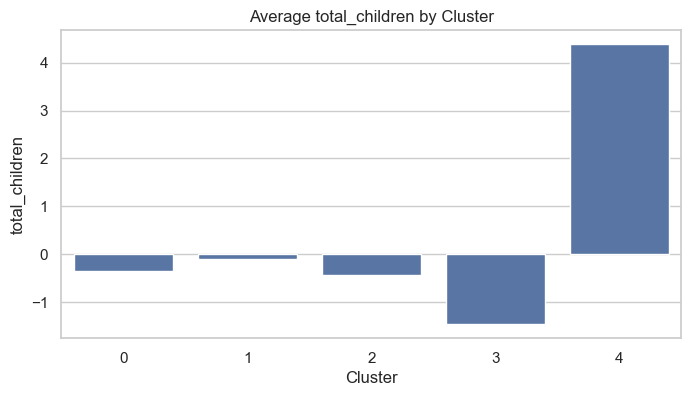

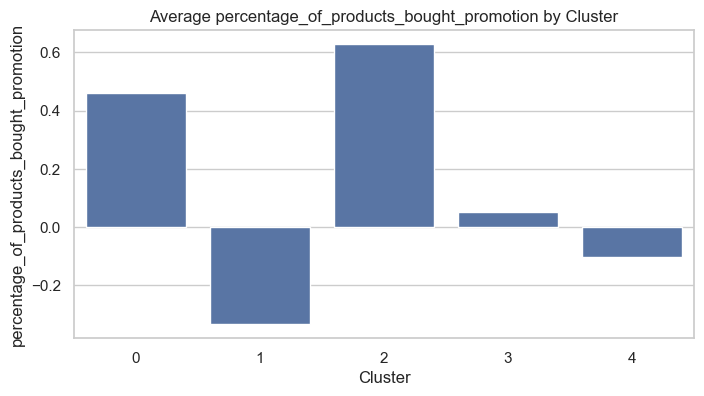

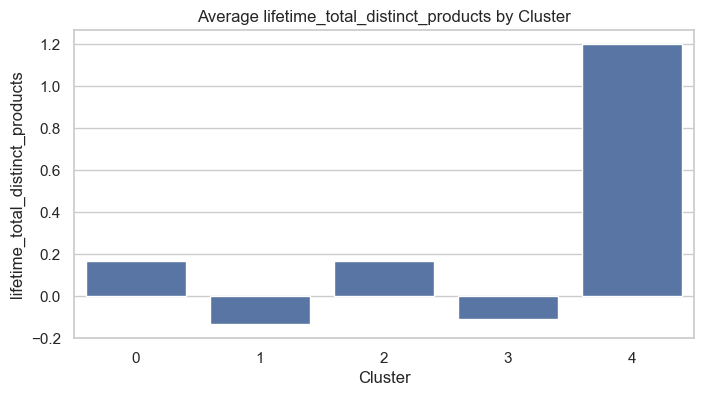

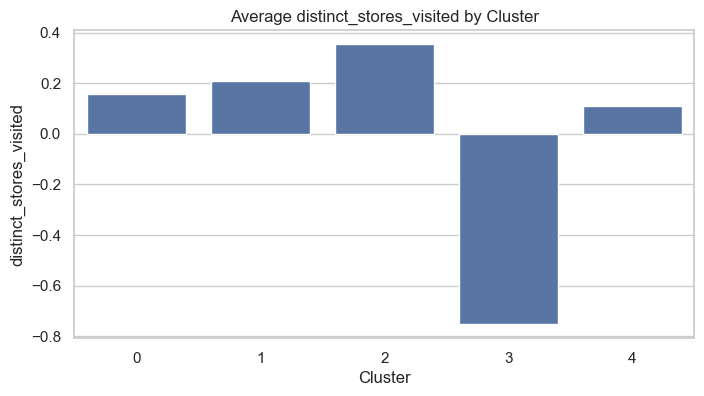

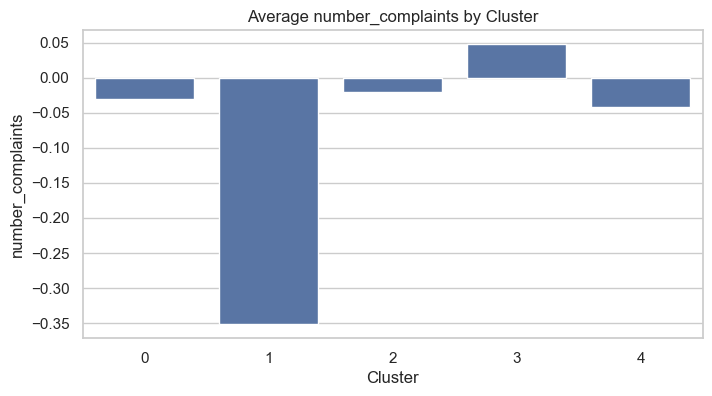

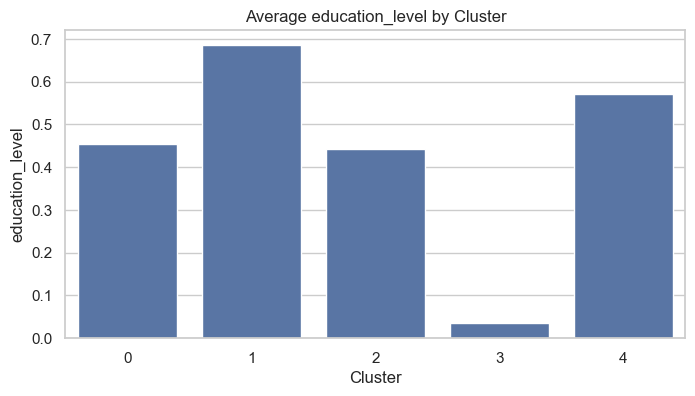

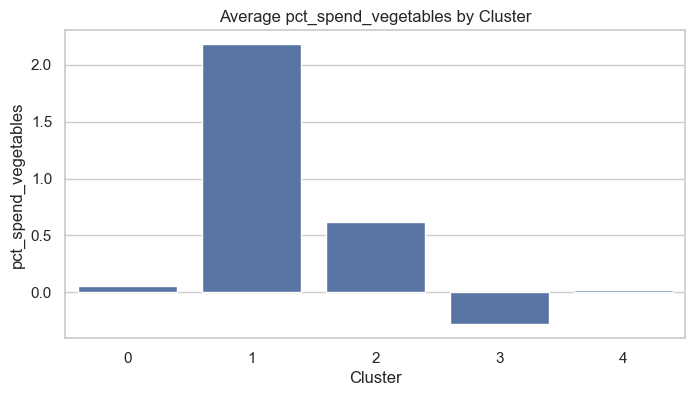

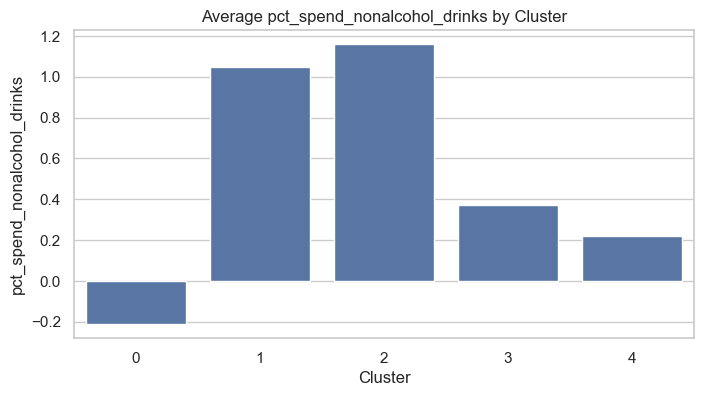

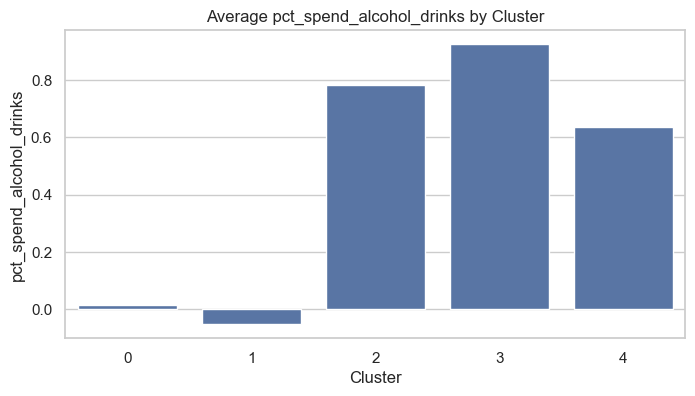

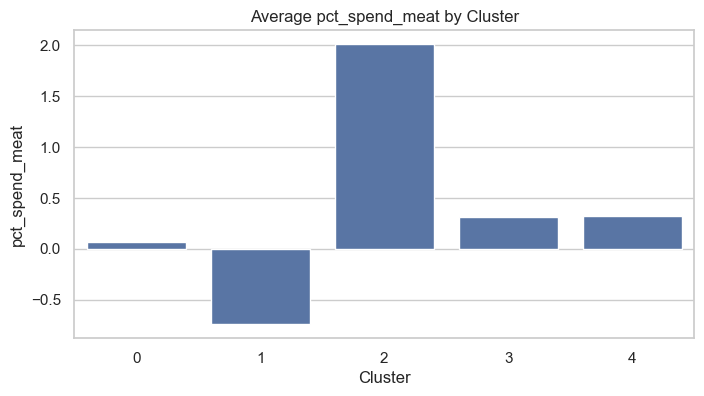

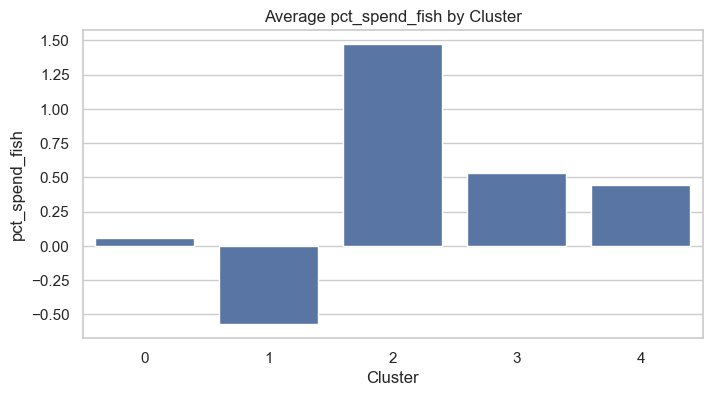

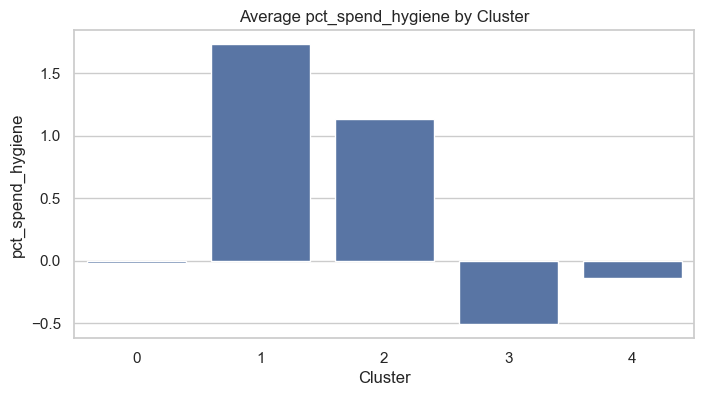

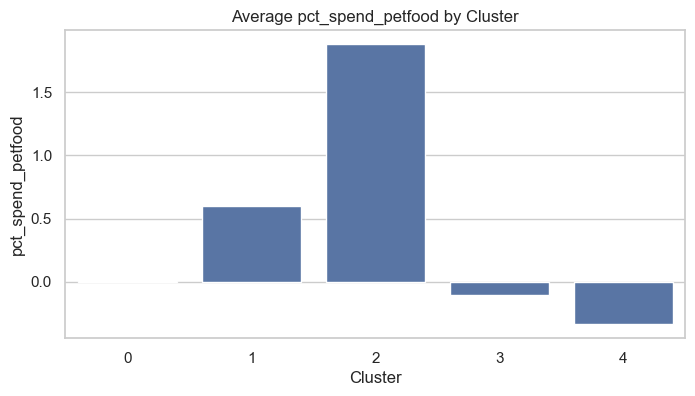

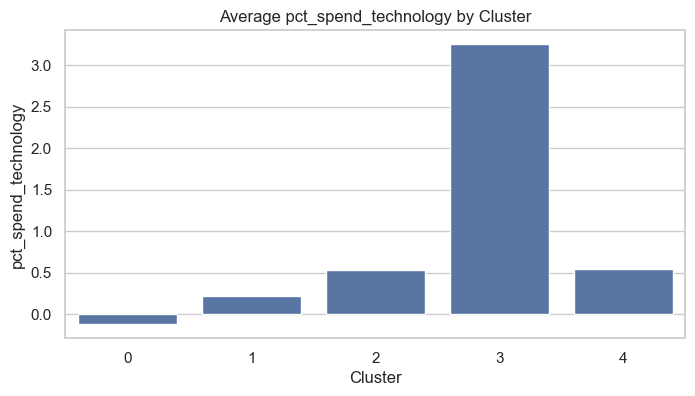

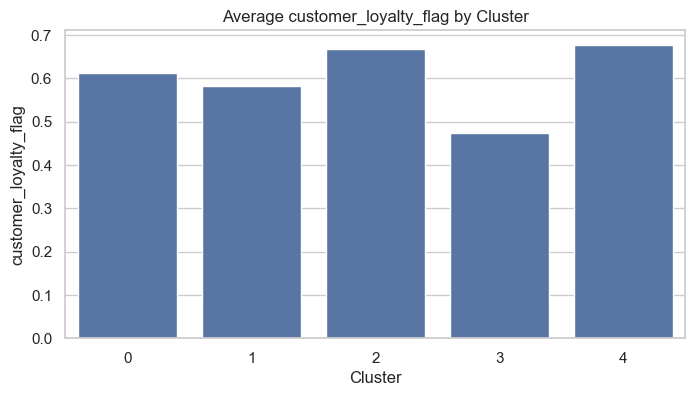

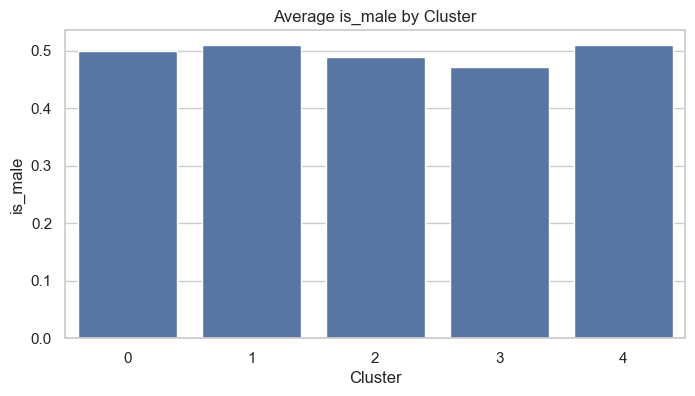

In [19]:
important_features = [
    "customer_age",
    "tenure",
    "total_children",
    "percentage_of_products_bought_promotion",
    "lifetime_total_distinct_products",
    "distinct_stores_visited",
    "number_complaints",
    "education_level",
    "pct_spend_vegetables",
    "pct_spend_nonalcohol_drinks",
    "pct_spend_alcohol_drinks",
    "pct_spend_meat",
    "pct_spend_fish",
    "pct_spend_hygiene",
    "pct_spend_petfood",
    "pct_spend_technology",
    "customer_loyalty_flag",
    "is_male"
]

clu.plot_cluster_feature_bars(
    customer_info_kmeans,
    cluster_col="kmeans_cluster",
    features=important_features
)

## 10. PCA, t-SNE and UMAP Visualizations

Dimensionality reduction techniques are used only for visualization. They help assess whether the final K-Means segments show coherent separation in lower-dimensional spaces.

Explained variance with 2 components: 0.3885


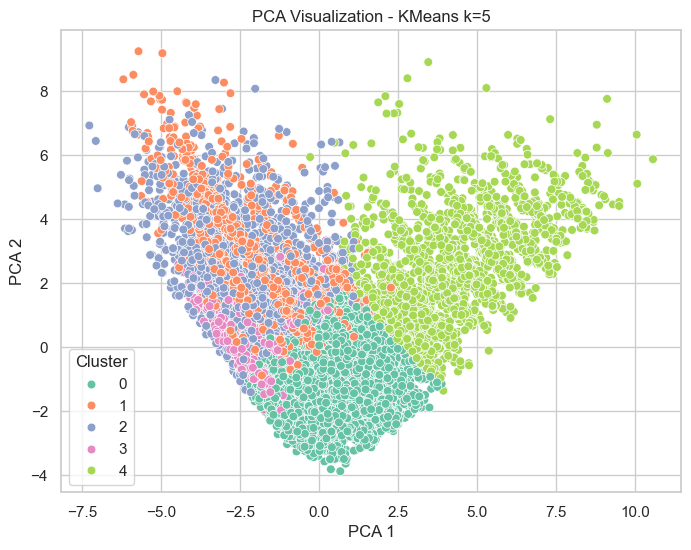

In [20]:
_ = clu.plot_pca_clusters(
    X,
    kmeans_labels,
    title="PCA Visualization - KMeans k=5"
)

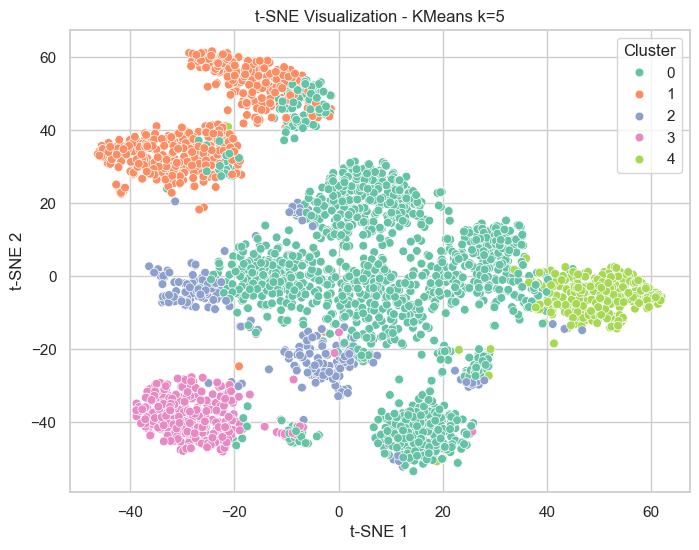

In [21]:
X_tsne_sample = X.sample(
    3000,
    random_state=42
)

kmeans_labels_tsne = customer_info_kmeans.loc[
    X_tsne_sample.index,
    "kmeans_cluster"
]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_embedding = tsne.fit_transform(X_tsne_sample)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=tsne_embedding[:, 0],
    y=tsne_embedding[:, 1],
    hue=kmeans_labels_tsne,
    palette="Set2",
    s=40
)

plt.title("t-SNE Visualization - KMeans k=5")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster")
plt.show()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


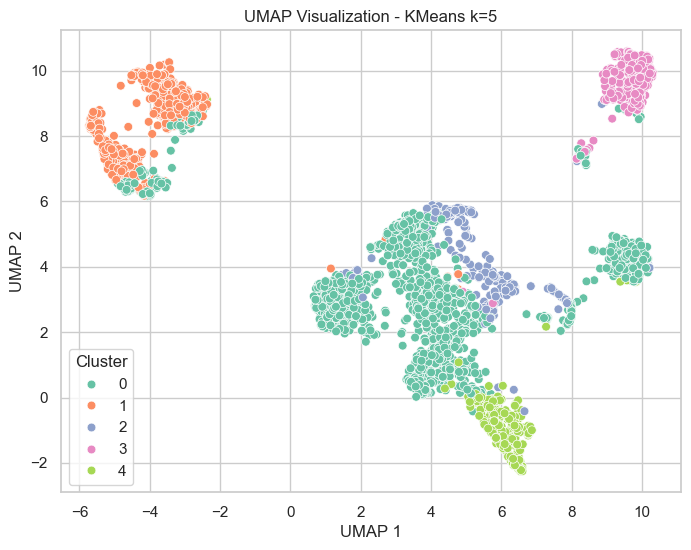

In [22]:
try:
    import umap.umap_ as umap

    X_umap_sample = X.sample(
        3000,
        random_state=42
    )

    kmeans_labels_umap = customer_info_kmeans.loc[
        X_umap_sample.index,
        "kmeans_cluster"
    ]

    umap_model = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )

    umap_embedding = umap_model.fit_transform(X_umap_sample)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=umap_embedding[:, 0],
        y=umap_embedding[:, 1],
        hue=kmeans_labels_umap,
        palette="Set2",
        s=40
    )

    plt.title("UMAP Visualization - KMeans k=5")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(title="Cluster")
    plt.show()

except ImportError:
    print("UMAP is not installed. Skipping UMAP visualization.")

## 11. Self-Organizing Map (SOM) Insights

A Self-Organizing Map was used as an additional exploratory tool. Unlike K-Means, the SOM is not used here as the final clustering model. Instead, it helps visualize the structure of the customer space and inspect how important features vary across the map.

In [25]:
som_weights, som_bmus, som_errors = clu.train_som(
    X,
    grid_size=(12, 12),
    n_iterations=2500,
    learning_rate=0.5,
    random_state=42,
    sample_size=8000
)

print(f"Mean quantization error: {som_errors.mean():.4f}")
print(f"Median quantization error: {np.median(som_errors):.4f}")


Mean quantization error: 2.4511
Median quantization error: 2.2683


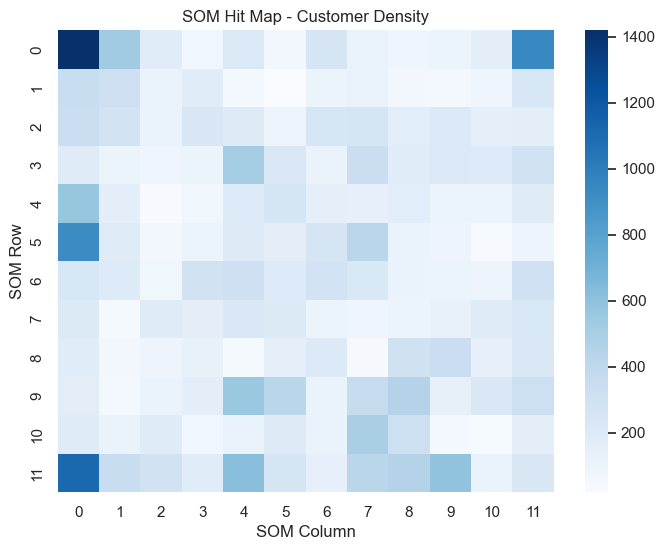

In [28]:
som_hit_map = clu.plot_som_hit_map(
    som_bmus,
    grid_size=(12, 12),
    title="SOM Hit Map - Customer Density"
)


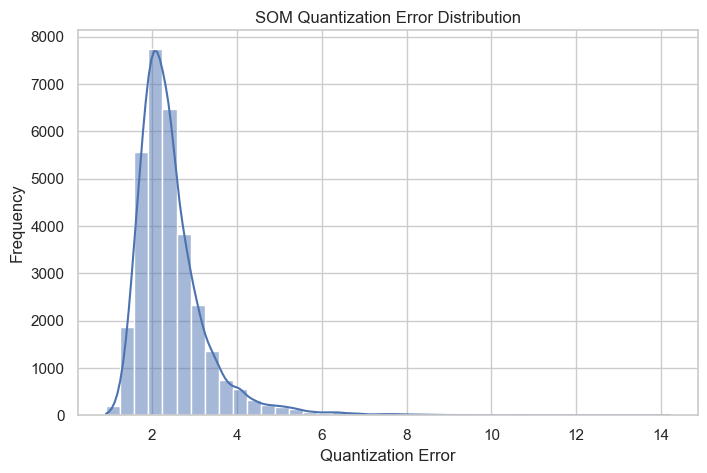

In [30]:
clu.plot_som_quantization_errors(som_errors)

In [32]:
import importlib
import utils_clustering as clu

importlib.reload(clu)

<module 'utils_clustering' from '/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_clustering.py'>

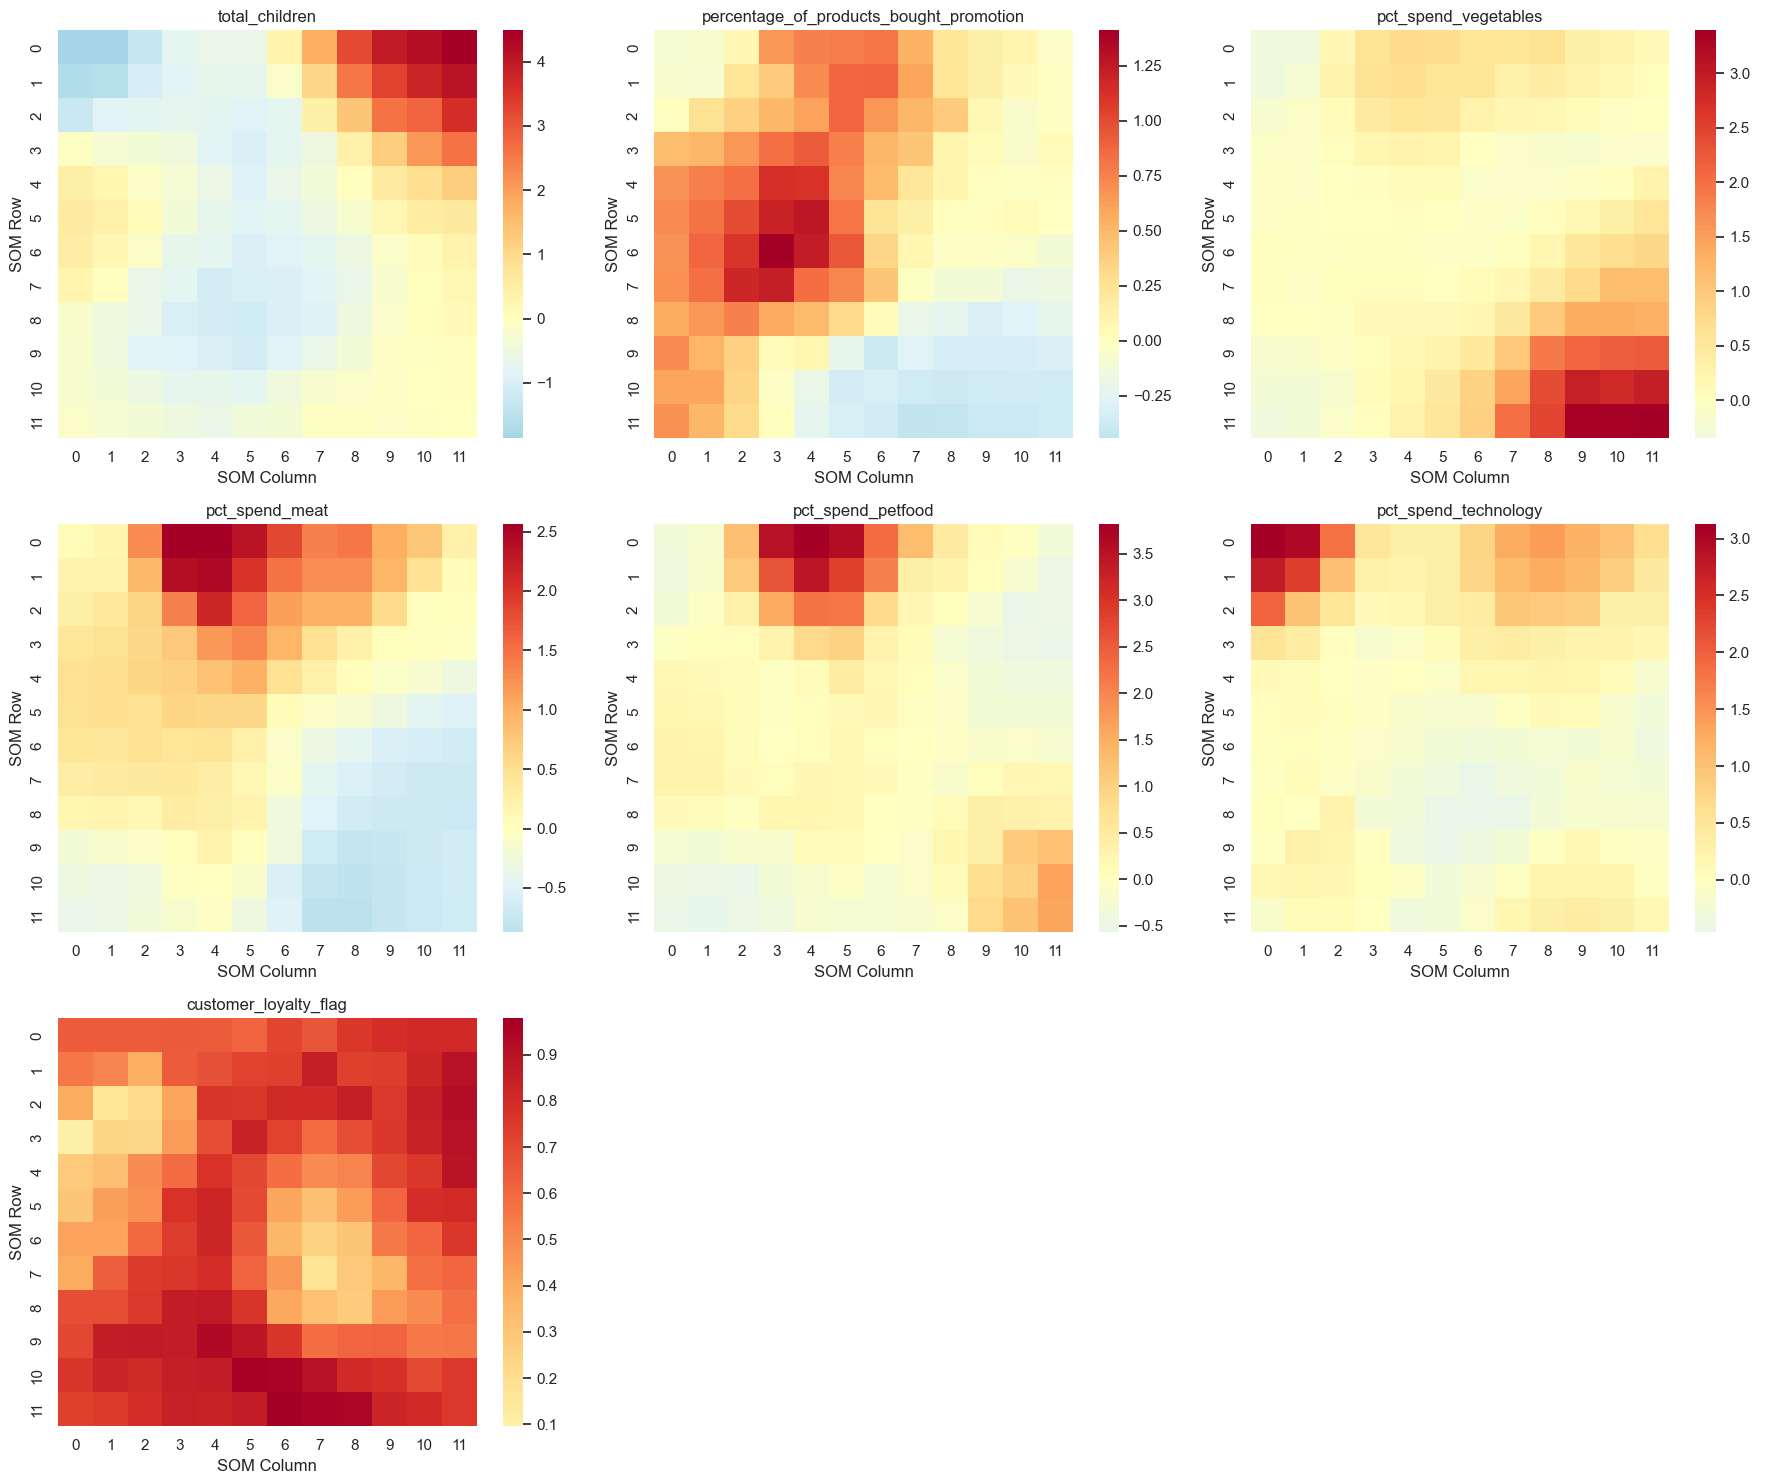

In [33]:
som_features = [
    "total_children",
    "percentage_of_products_bought_promotion",
    "pct_spend_vegetables",
    "pct_spend_meat",
    "pct_spend_petfood",
    "pct_spend_technology",
    "customer_loyalty_flag"
]

clu.plot_som_feature_maps(
    som_weights,
    feature_names=list(X.columns),
    selected_features=som_features,
    grid_size=(12, 12)
)


The SOM visualizations are used to support interpretation rather than to replace the final model. The hit map highlights dense regions in the customer space, while the feature maps show how household, promotion and product-category behaviors vary across the map.

## 12. Hierarchical Clustering

Hierarchical clustering was tested as an alternative method to validate whether a similar segmentation structure could be found using a different clustering approach.

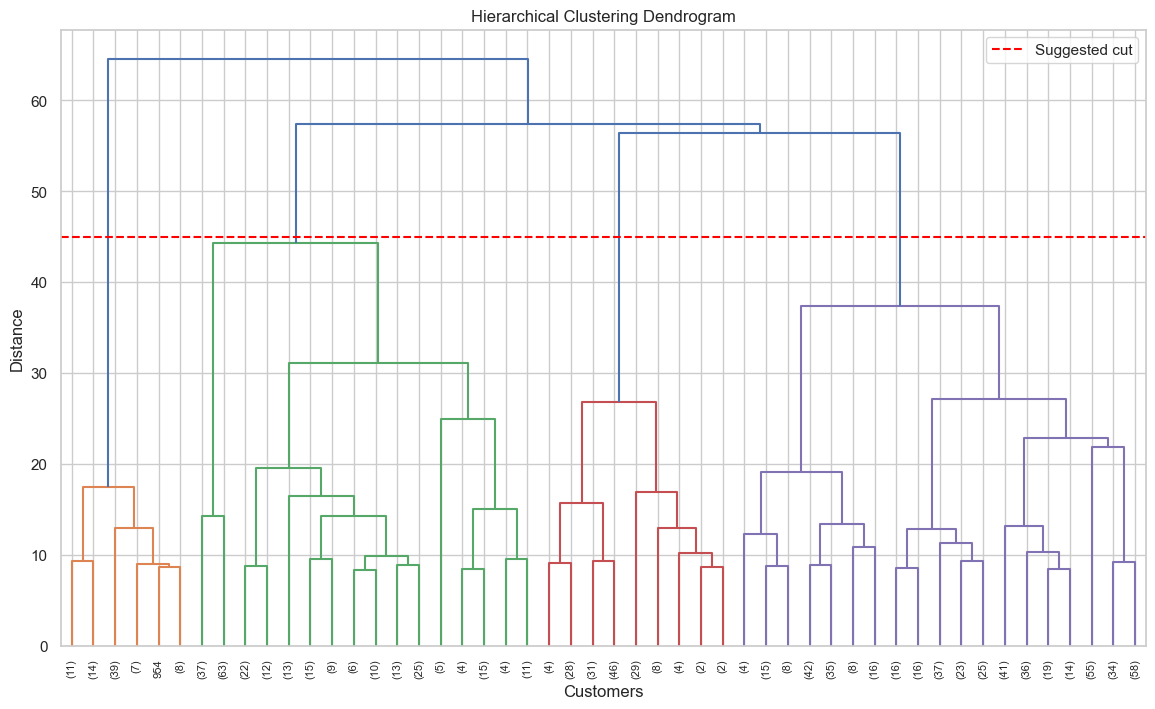

In [34]:
X_sample = X.sample(
    1000,
    random_state=42
)

linkage_matrix = linkage(
    X_sample,
    method="ward"
)

plt.figure(figsize=(14, 8))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=50,
    leaf_rotation=90
)

plt.axhline(
    y=45,
    color="red",
    linestyle="--",
    label="Suggested cut"
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.legend()
plt.show()


The dendrogram suggests a reasonable partition around five groups, supporting the `k=4` segmentation used in the final K-Means model.

In [35]:
hier_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hier_labels = hier_model.fit_predict(X)

customer_info_hier = df.copy()
customer_info_hier["hierarchical_cluster"] = hier_labels

clu.cluster_distribution(hier_labels)

0     6044
1    16451
2     6754
3     2637
Name: count, dtype: int64

In [36]:
hier_metrics = clu.evaluate_clustering(
    X,
    hier_labels,
    model_name="Hierarchical k=4"
)

hier_metrics

,Model,Clusters,Silhouette Score
0,Hierarchical k=5,4,0.170558


Explained variance with 2 components: 0.3885


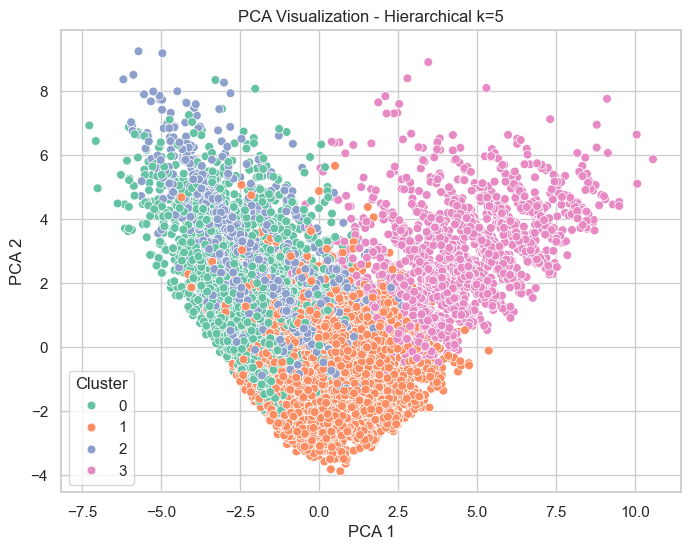

In [37]:
_ = clu.plot_pca_clusters(
    X,
    hier_labels,
    title="PCA Visualization - Hierarchical k=4"
)

## 13. K-Means vs Hierarchical Agreement

This heatmap compares the final K-Means solution with the Hierarchical Clustering solution. Strong concentration in specific cells indicates that the methods identify similar structures.

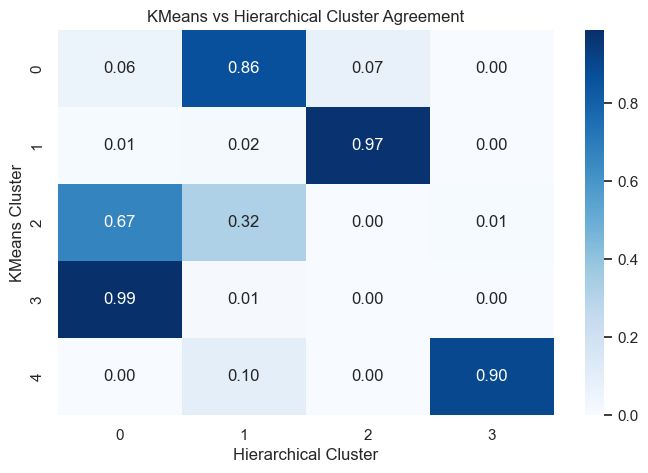

hierarchical_cluster,0,1,2,3
kmeans_cluster,,,,
0,0.06,0.86,0.07,0.00
1,0.01,0.02,0.97,0.00
2,0.67,0.32,0.00,0.01
3,0.99,0.01,0.00,0.00
4,0.00,0.10,0.00,0.90


In [38]:
cluster_agreement = pd.crosstab(
    customer_info_kmeans["kmeans_cluster"],
    customer_info_hier["hierarchical_cluster"],
    normalize="index"
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    cluster_agreement,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)
plt.title("KMeans vs Hierarchical Cluster Agreement")
plt.xlabel("Hierarchical Cluster")
plt.ylabel("KMeans Cluster")
plt.show()

cluster_agreement.round(2)

## 14. DBSCAN

DBSCAN was tested as a density-based clustering method. It is useful when clusters have clear density separation, but it can struggle with high-dimensional customer datasets and heterogeneous densities.

In [39]:
dbscan_model = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan_model.fit_predict(X)

customer_info_dbscan = df.copy()
customer_info_dbscan["dbscan_cluster"] = dbscan_labels

clu.cluster_distribution(dbscan_labels)

-1     19797
 0      8388
 1      1591
 2      1684
 3        18
 4       244
 5        13
 6        12
 7       108
 8        18
 9         8
 10        5
Name: count, dtype: int64

In [40]:
dbscan_metrics = clu.evaluate_clustering(
    X,
    dbscan_labels,
    model_name="DBSCAN"
)

dbscan_metrics

,Model,Clusters,Silhouette Score
0,DBSCAN,11,-0.174075


Explained variance with 2 components: 0.3885


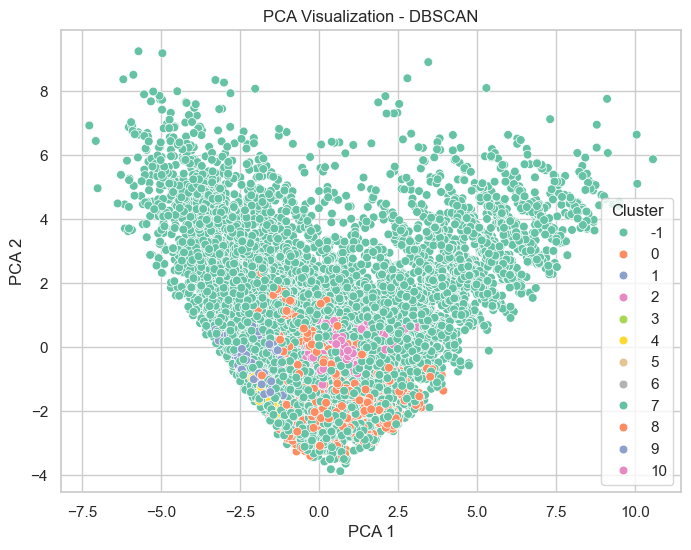

In [41]:
_ = clu.plot_pca_clusters(
    X,
    dbscan_labels,
    title="PCA Visualization - DBSCAN"
)

## 15. Mean Shift

Mean Shift was also tested as a density-based method. Because it can be computationally expensive, it was evaluated on a sample of the dataset.

In [42]:
X_meanshift_sample = X.sample(
    5000,
    random_state=42
)

bandwidth = estimate_bandwidth(
    X_meanshift_sample,
    quantile=0.2,
    n_samples=1000,
    random_state=42
)

bandwidth

np.float64(4.425468731395639)

In [43]:
meanshift_model = MeanShift(
    bandwidth=bandwidth,
    bin_seeding=True
)

meanshift_labels = meanshift_model.fit_predict(X_meanshift_sample)

clu.cluster_distribution(meanshift_labels)

0    4895
1      86
2      19
Name: count, dtype: int64

In [44]:
meanshift_metrics = clu.evaluate_clustering(
    X_meanshift_sample,
    meanshift_labels,
    model_name="Mean Shift"
)

meanshift_metrics

,Model,Clusters,Silhouette Score
0,Mean Shift,3,0.400286


Explained variance with 2 components: 0.3856


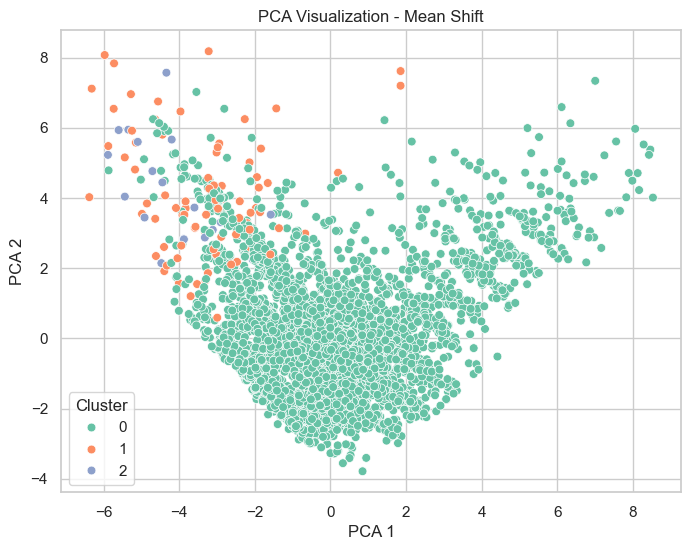

In [45]:
_ = clu.plot_pca_clusters(
    X_meanshift_sample,
    meanshift_labels,
    title="PCA Visualization - Mean Shift"
)

## 16. Model Comparison

The final model comparison uses Silhouette Score as the quantitative metric. However, model selection also considers interpretability, cluster size balance and usefulness for customer segmentation.

In [46]:
comparison = pd.concat(
    [
        kmeans_metrics,
        hier_metrics,
        dbscan_metrics,
        meanshift_metrics
    ],
    ignore_index=True
)

comparison

,Model,Clusters,Silhouette Score
0,KMeans k=5,5,0.219026
1,Hierarchical k=5,4,0.170558
2,DBSCAN,11,-0.174075
3,Mean Shift,3,0.400286


### Why K-Means Was Selected

K-Means with `k=5` was selected as the final model because it provided the best balance between statistical performance, visual separation and business interpretability.

Although Mean Shift may produce a higher silhouette score, it assigns most observations to one dominant cluster, which makes it less useful for customer segmentation. DBSCAN was not selected because it produced weak separation and many noisy observations. Hierarchical clustering was useful as a comparison method, but K-Means produced clearer and more actionable final segments.

## 17. Optional: Assign Removed Outliers to the Nearest K-Means Centroid

During preprocessing, extreme spenders were stored separately so they would not distort the clustering model. After the final K-Means model is trained, these customers can be assigned to the closest existing centroid.

This step is only executed if the outlier dataset has the same clustering features as the model input. If the columns are not aligned, the notebook skips the assignment to avoid an incorrect result.

In [47]:
outlier_path = "../datasets/outlier_dataset.csv"

if os.path.exists(outlier_path):
    outlier_dataset = pd.read_csv(outlier_path)

    try:
        assigned_outliers = clu.assign_outliers_to_nearest_centroid(
            outlier_dataset,
            feature_columns=X.columns,
            kmeans_model=kmeans_model,
            cluster_col="kmeans_cluster"
        )

        assigned_outliers, _ = clu.add_segment_names(
            assigned_outliers,
            cluster_col="kmeans_cluster",
            name_col="segment_name"
        )

        assigned_outliers = clu.add_recommendations(
            assigned_outliers,
            name_col="segment_name",
            action_col="recommended_action"
        )

        final_clustered_dataset = pd.concat(
            [customer_info_kmeans, assigned_outliers],
            ignore_index=True
        )

        print("Outliers assigned successfully.")
        print("Final dataset shape:", final_clustered_dataset.shape)

    except ValueError as error:
        print("Outlier assignment skipped:")
        print(error)
        final_clustered_dataset = customer_info_kmeans.copy()
else:
    print("Outlier dataset not found. Continuing with the main clustered dataset only.")
    final_clustered_dataset = customer_info_kmeans.copy()

Outliers assigned successfully.
Final dataset shape: (32047, 42)


## 18. Segment-Based Business Recommendations

After naming the final clusters, simple business actions were assigned to each segment. These recommendations are based on the cluster profile and should support later marketing and basket-analysis work.

In [48]:
customer_info_kmeans = clu.add_recommendations(
    customer_info_kmeans,
    name_col="segment_name",
    action_col="recommended_action"
)

segment_recommendations = (
    customer_info_kmeans[["segment_name", "recommended_action"]]
    .drop_duplicates()
    .sort_values("segment_name")
)

segment_recommendations

,segment_name,recommended_action
26,Family Loyal Customers,"Offer family packs, loyalty rewards, bulk disc..."
1,Healthy Lifestyle Buyers,"Promote fresh produce, hygiene products, welln..."
13,Premium Grocery & Pet Buyers,"Use cross-category bundles involving meat, fis..."
0,Promotion-Oriented Regulars,"Use discount campaigns, personalized coupons, ..."
3,Tech-Focused Customers,"Target with technology offers, new product lau..."


In [ ]:
customer_info_kmeans[[
    "customer_id",
    "kmeans_cluster",
    "segment_name",
    "recommended_action"
]].head()

## 19. Export Final Results

The final outputs are exported for later use in cluster characterization, basket analysis and marketing strategy.

In [ ]:
# Ensure customer_id is stored as an integer identifier when possible
for _df in [customer_info_kmeans, final_clustered_dataset]:
    if "customer_id" in _df.columns:
        _df["customer_id"] = _df["customer_id"].astype(int)

output_dir = "../datasets"
os.makedirs(output_dir, exist_ok=True)

final_clustered_dataset.to_csv(
    os.path.join(output_dir, "customer_segments_final.csv"),
    index=False
)

customer_info_kmeans[[
    "customer_id",
    "kmeans_cluster",
    "segment_name",
    "recommended_action"
]].to_csv(
    os.path.join(output_dir, "customer_segments_main_only.csv"),
    index=False
)

kmeans_profile.to_csv(
    os.path.join(output_dir, "kmeans_cluster_profile.csv")
)

comparison.to_csv(
    os.path.join(output_dir, "clustering_model_comparison.csv"),
    index=False
)

print("Final clustering files exported successfully.")